# BIM 432 - House M.D. Do?al Dil ??leme Projesi

Bu notebook `DATA/Last_HouseMD_DataSet.csv` dosyas?n? kullanarak House M.D. repliklerinden/vaka kay?tlar?ndan tan? etiketi tahmini yapan u?tan uca bir NLP ?al??mas?d?r.

Kapsanan proje g?revleri:

1. **Veri setinin haz?rlanmas?:** CSV okuma, kolon kontrol?, eksik/bozuk hedeflerin ayr?lmas?, veri kalitesi raporu.
2. **?n i?leme ve ?zellik se?imi:** T?rk?e metin normalizasyonu, t?bbi varl?k ??kar?m?, e? anlaml? tan? etiketlerinin birle?tirilmesi, case-aware vaka ba?lam? ?retimi.
3. **Modelleme:** Ayn? veri ve ayn? ?zellik dosyas? ?zerinde ?? model e?itilir: Complement Naive Bayes, Passive-Aggressive ve SGD Modified Huber.
4. **Canl?ya alma ve etik:** En iyi model `models/best_housemd_diagnosis_model.joblib` olarak paketlenir; bot tahmini ve etik uyar? fonksiyonlar? eklenir.
5. **Yaz?l? rapor / s?zl? sunum:** Notebook sonunda do?rudan rapora ve sunuma ta??nabilecek ?zet yer al?r.

Final model tek replik yerine vaka ba?lam?n? da kullanan **case-aware** bir modeldir. Vaka ba?lam? hedef etiketi veya ?nceki model tahmini kullanmaz; yaln?zca ayn? sezon/b?l?m i?indeki semptom, test, ila?, prosed?r, organ ve `medical_entities` bilgilerinden ?retilir.

In [1]:
import json
import re
import unicodedata
import warnings
from pathlib import Path
from datetime import datetime

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import PassiveAggressiveClassifier, SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import ComplementNB
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 160)
sns.set_theme(style="whitegrid", font_scale=0.9)

In [2]:
DATA_PATH = Path("DATA") / "Last_HouseMD_DataSet.csv"
MODEL_PATH = Path("models") / "best_housemd_diagnosis_model.joblib"
TARGET_COLUMN = "correct_prediction"
RANDOM_STATE = 42
TEST_SIZE = 0.20
MIN_CLASS_COUNT = 20
CASE_CONTEXT_TOKEN_LIMIT = 320
SELECTION_METRIC = "test_macro_f1"

TEXT_FEATURE_COLUMNS = ["text", "Symptom", "Test", "Drug", "Procedure", "Organ"]
META_FEATURE_COLUMNS = ["speaker", "Intent", "diagnosis_stage", "Emotion", "Sarcasm"]
CASE_CONTEXT_COLUMNS = ["Symptom", "Test", "Drug", "Procedure", "Organ", "medical_entities"]
EXCLUDED_LEAKAGE_COLUMNS = ["correct_prediction", "model_prediction"]

print("Data file:", DATA_PATH.resolve())
print("Target column:", TARGET_COLUMN)
print("Model artifact:", MODEL_PATH.resolve())

Data file: C:\Users\moham\Desktop\NLP_Project\DATA\Last_HouseMD_DataSet.csv
Target column: correct_prediction
Model artifact: C:\Users\moham\Desktop\NLP_Project\models\best_housemd_diagnosis_model.joblib


## 1. Veri Setinin Haz?rlanmas?

CSV dosyas? `;` ayrac? ile okunur. B?t?n kolonlar ?nce metin olarak al?n?r; b?ylece kar???k tipli alanlardan dolay? veri kayb? olmaz.

In [3]:
df_raw = pd.read_csv(
    DATA_PATH,
    sep=";",
    encoding="utf-8-sig",
    dtype=str,
    on_bad_lines="warn",
).fillna("")

for column in df_raw.columns:
    df_raw[column] = df_raw[column].astype(str).str.strip()

raw_row_count = len(df_raw)
blank_row_mask = df_raw.apply(lambda row: all(str(value).strip() == "" for value in row), axis=1)
blank_row_count = int(blank_row_mask.sum())
df_raw = df_raw.loc[~blank_row_mask].reset_index(drop=True)

print("Raw rows read:", raw_row_count)
print("Fully blank rows removed:", blank_row_count)
print("Rows after cleanup:", len(df_raw))
print("Columns:", list(df_raw.columns))
display(df_raw.head())

Raw rows read: 7282
Fully blank rows removed: 0
Rows after cleanup: 7282
Columns: ['season', 'episode', 'speaker', 'Symptom', 'Test', 'Drug', 'Procedure', 'Intent', 'diagnosis_stage', 'Sarcasm', 'Emotion', 'Organ', 'correct_prediction', 'model_prediction', 'text', 'medical_entities']


,season,episode,speaker,Symptom,Test,Drug,Procedure,Intent,diagnosis_stage,Sarcasm,Emotion,Organ,correct_prediction,model_prediction,text,medical_entities
0,1,1,Wilson,nöbet,,,,açıklama,hipotez,0,nötr,beyin,nörosistiserkozis,,29 yaşında bir kadın hasta; ilk nöbetini bir ay önce geçirmiş.,"[{""text"": ""nöbet"", ""type"": ""Symptom""}]"
1,1,1,Wilson,afazi,,,,açıklama,hipotez,0,nötr,beyin,nörosistiserkozis,,"Konuşma yetisini kaybetmiş, bebek gibi anlamsız sesler çıkarıyor.","[{""text"": ""afazi"", ""type"": ""Symptom""}]"
2,1,1,Wilson,zihinsel durum bozukluğu,,,,açıklama,hipotez,0,nötr,beyin,nörosistiserkozis,,Mental durumu giderek kötüleşiyor.,"[{""text"": ""zihinsel durum bozukluğu"", ""type"": ""Symptom""}]"
3,1,1,House,,,,,şaka,hipotez,1,alaycı,beyin,nörosistiserkozis,,Beyin tümörü dediler; ben olsam ben de o tanıyı sevmezdim. Ölecek demenin sıkıcı bir yolu.,"[{""text"": ""beyin tümörü"", ""type"": ""Disease""}]"
4,1,1,Wilson,,,,,açıklama,hipotez,0,nötr,beyin,nörosistiserkozis,,Onun yaşında beyin tümörü olması pek olası değil.,"[{""text"": ""beyin tümörü"", ""type"": ""Disease""}]"


,column,missing_count,missing_ratio,unique_count
13,model_prediction,5874,0.8066,311
6,Procedure,5074,0.6968,613
5,Drug,5051,0.6936,573
4,Test,4614,0.6336,885
3,Symptom,2637,0.3621,2685
11,Organ,2164,0.2972,759
12,correct_prediction,1470,0.2019,655
7,Intent,200,0.0275,218
15,medical_entities,139,0.0191,5760
10,Emotion,2,0.0003,248


Ham hedef etiketi say?s?: 655
Bo? hedef sat?r?: 1470


,count
correct_prediction,
,1470
nörosistiserkozis,422
none,192
1,180
melanom,100
fosmet ile kontamine kıyafetlere bağlı organofosfat zehirlenmesi,69
Travma Sonrası Siringomyeli,65
amiloidoz,64
kimerizm,63


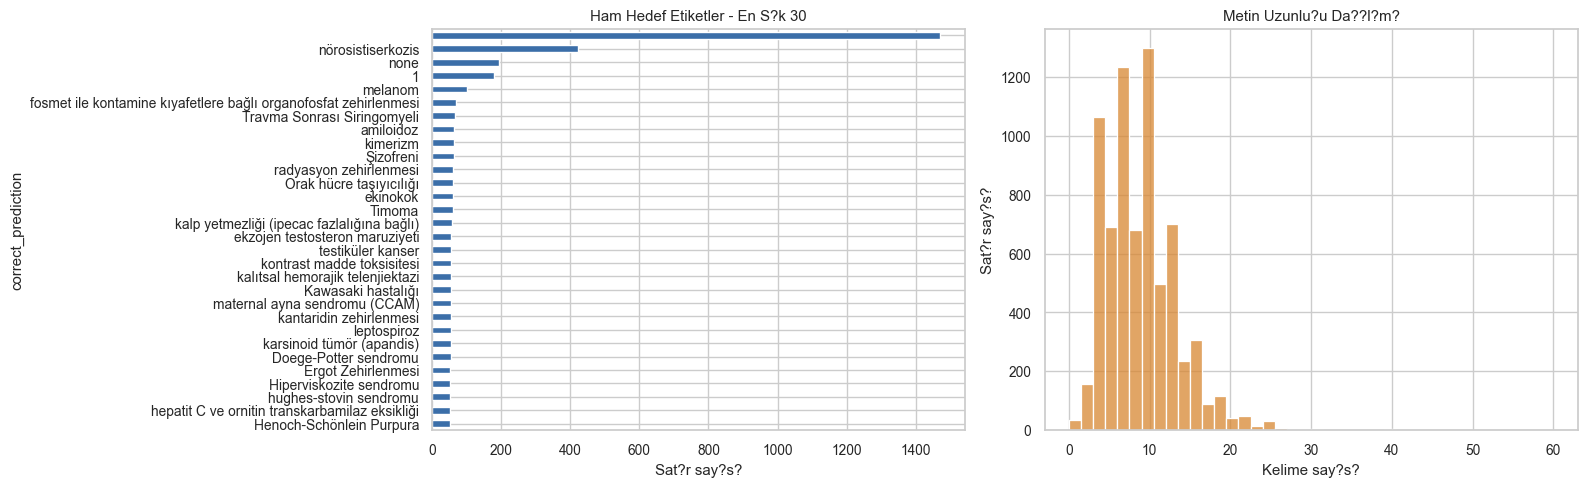

In [4]:
quality_report = pd.DataFrame({
    "column": df_raw.columns,
    "missing_count": [(df_raw[col].str.strip() == "").sum() for col in df_raw.columns],
    "missing_ratio": [round((df_raw[col].str.strip() == "").mean(), 4) for col in df_raw.columns],
    "unique_count": [df_raw[col].nunique(dropna=False) for col in df_raw.columns],
}).sort_values("missing_ratio", ascending=False)

display(quality_report)

raw_target_counts = df_raw[TARGET_COLUMN].fillna("").astype(str).str.strip().value_counts(dropna=False)
print("Ham hedef etiketi say?s?:", raw_target_counts.size)
print("Bo? hedef sat?r?:", int((df_raw[TARGET_COLUMN].str.strip() == "").sum()))
display(raw_target_counts.head(35).to_frame("count"))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
raw_target_counts.head(30).sort_values().plot(kind="barh", ax=axes[0], color="#3b6ea8")
axes[0].set_title("Ham Hedef Etiketler - En S?k 30")
axes[0].set_xlabel("Sat?r say?s?")
axes[0].set_ylabel(TARGET_COLUMN)

text_lengths = df_raw["text"].fillna("").astype(str).str.split().str.len()
sns.histplot(text_lengths, bins=40, ax=axes[1], color="#d88732")
axes[1].set_title("Metin Uzunlu?u Da??l?m?")
axes[1].set_xlabel("Kelime say?s?")
axes[1].set_ylabel("Sat?r say?s?")
plt.tight_layout()
plt.show()

## 2. ?n ??leme ve ?zellik Se?imi

Bu b?l?mde T?rk?e karakterleri koruyan metin normalizasyonu yap?l?r. `correct_prediction`, `model_prediction`, sezon ve b?l?m numaras? do?rudan modele verilmez. Bunun yerine ayn? vaka i?indeki klinik alanlardan **case-aware ba?lam** ?retilir.

In [5]:
TURKISH_CHARS = "??????"
TR_STOPWORDS = {
    "acaba", "ama", "aslinda", "az", "bazi", "belki", "biri", "birkac", "birsey",
    "biz", "bu", "cok", "cunku", "da", "daha", "de", "defa", "diye", "eger",
    "en", "gibi", "hem", "hep", "hepsi", "her", "hic", "icin", "ile", "ise",
    "kez", "ki", "kim", "mi", "mu", "nasil", "ne", "neden", "nerede", "nereye",
    "nicin", "niye", "o", "sanki", "sey", "siz", "su", "tum", "ve", "veya",
    "ya", "yani", "ben", "sen", "onlar", "bizim", "sizin", "var", "yok",
}
INVALID_LABELS = {"", "none", "nan", "1", "0", "-"}

LABEL_SYNONYM_MAP = {
    "wilson hastal??? tan?s?": "wilson hastal???",
    "ipecac fazlal???na ba?l?": "ipecac zehirlenmesi / kalp yetmezli?i",
    "kalp yetmezli?i ipecac fazlal???na ba?l?": "ipecac zehirlenmesi / kalp yetmezli?i",
    "kalp yetmezli?i / ipecac fazlal???na ba?l?": "ipecac zehirlenmesi / kalp yetmezli?i",
    "ipecac ?urubu zehirlenmesi": "ipecac zehirlenmesi / kalp yetmezli?i",
    "munchausen sendromu ve ipecac zehirlenmesi": "ipecac zehirlenmesi / kalp yetmezli?i",
    "c?zzam leprozi": "c?zzam / leprozi",
    "leprozi": "c?zzam / leprozi",
    "sjogren sendromu": "sj?gren sendromu",
    "fosmet ile kont m3 m82amine k?yafetlere ba?l? organofosfat zehirlenmesi": "fosmet ile kontamine k?yafetlere ba?l? organofosfat zehirlenmesi",
}


def normalize_text(value):
    if pd.isna(value):
        return ""
    text = unicodedata.normalize("NFKC", str(value)).lower().replace("\u0307", "")
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(f"[^0-9a-z{TURKISH_CHARS}\s\-/+%.]", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def normalize_label(value):
    label = normalize_text(value).replace("(", " ").replace(")", " ")
    label = re.sub(r"\s*/\s*", " / ", label)
    return re.sub(r"\s+", " ", label).strip()


def canonicalize_label(value):
    label = normalize_label(value)
    if label in INVALID_LABELS:
        return label

    label = re.sub(r"\btan?s?\b", "", label).strip()
    label = re.sub(r"\s+", " ", label)

    if label in LABEL_SYNONYM_MAP:
        return LABEL_SYNONYM_MAP[label]
    if "fosmet" in label and "organofosfat" in label:
        return "fosmet ile kontamine k?yafetlere ba?l? organofosfat zehirlenmesi"
    if "ipecac" in label:
        return "ipecac zehirlenmesi / kalp yetmezli?i"
    if label in {"sj?gren sendromu", "sjogren sendromu"}:
        return "sj?gren sendromu"
    if label in {"c?zzam", "c?zzam leprozi", "leprozi"}:
        return "c?zzam / leprozi"
    return label


def extract_medical_entities(value):
    if pd.isna(value) or not str(value).strip():
        return ""

    raw = str(value).strip().replace('""', '"')
    tokens = []
    entity_texts = re.findall(r'"text"\s*:\s*"([^"]+)"', raw)
    entity_types = re.findall(r'"type"\s*:\s*"([^"]+)"', raw)

    tokens.extend(normalize_text(text) for text in entity_texts)
    tokens.extend("entity_" + normalize_text(kind).replace(" ", "_") for kind in entity_types)
    return " ".join(token for token in tokens if token)


def build_row_text(row):
    parts = []

    for col in TEXT_FEATURE_COLUMNS:
        value = normalize_text(row.get(col, ""))
        if value:
            parts.append(value)

    for col in META_FEATURE_COLUMNS:
        value = normalize_text(row.get(col, ""))
        if value:
            parts.append(f"{col.lower()}_{value.replace(' ', '_')}")

    entities = extract_medical_entities(row.get("medical_entities", ""))
    if entities:
        parts.append(entities)

    return " ".join(parts)


def unique_token_join(values, limit=CASE_CONTEXT_TOKEN_LIMIT):
    seen = []
    for value in values:
        for token in str(value).split():
            if token and token not in seen:
                seen.append(token)
            if len(seen) >= limit:
                return " ".join(seen)
    return " ".join(seen)

In [6]:
df = df_raw.copy()
df["target_raw_clean"] = df[TARGET_COLUMN].apply(normalize_label)
df["target"] = df[TARGET_COLUMN].apply(canonicalize_label)
df["row_text"] = df.apply(build_row_text, axis=1)
df["fact_text"] = df[["Symptom", "Test", "Drug", "Procedure", "Organ"]].apply(
    lambda row: " ".join(normalize_text(value) for value in row if normalize_text(value)),
    axis=1,
)
df["entity_text"] = df["medical_entities"].apply(extract_medical_entities)

case_context = (
    df.groupby(["season", "episode"])[["fact_text", "entity_text"]]
    .agg(lambda values: unique_token_join([normalize_text(value) for value in values]))
    .reset_index()
)
case_context["case_context"] = (case_context["fact_text"] + " " + case_context["entity_text"]).str.strip()

df = df.merge(case_context[["season", "episode", "case_context"]], on=["season", "episode"], how="left")
df["model_text"] = (df["row_text"] + " vaka_baglam " + df["case_context"].fillna("")).str.strip()

before_rows = len(df)
invalid_target_mask = df["target"].isin(INVALID_LABELS)
empty_text_mask = df["row_text"].str.len().eq(0)

df_clean = df.loc[~invalid_target_mask & ~empty_text_mask].copy()
raw_valid_class_count = df_clean["target_raw_clean"].nunique()
canonical_class_count = df_clean["target"].nunique()

target_counts = df_clean["target"].value_counts()
eligible_classes = target_counts[target_counts >= MIN_CLASS_COUNT].index
rare_class_count = int((target_counts < MIN_CLASS_COUNT).sum())
rare_row_count = int(target_counts[target_counts < MIN_CLASS_COUNT].sum())

df_model = df_clean[df_clean["target"].isin(eligible_classes)].copy()
before_dedup = len(df_model)
df_model = df_model.drop_duplicates(subset=["row_text", "target"]).reset_index(drop=True)
duplicate_rows_removed = before_dedup - len(df_model)

cleaning_audit = pd.DataFrame([
    {"step": "raw_rows", "rows": int(before_rows)},
    {"step": "invalid_or_empty_target_removed", "rows": int(invalid_target_mask.sum())},
    {"step": "empty_text_removed", "rows": int((~invalid_target_mask & empty_text_mask).sum())},
    {"step": f"rare_classes_removed_less_than_{MIN_CLASS_COUNT}", "rows": rare_row_count},
    {"step": "duplicate_row_text_target_removed", "rows": int(duplicate_rows_removed)},
    {"step": "final_model_rows", "rows": int(len(df_model))},
])

display(cleaning_audit)
print("Valid raw class count:", raw_valid_class_count)
print("Canonical class count before rare filtering:", canonical_class_count)
print("Rare classes removed:", rare_class_count)
print("Final model rows/classes:", len(df_model), "/", df_model["target"].nunique())

,step,rows
0,raw_rows,7282
1,invalid_or_empty_target_removed,1867
2,empty_text_removed,0
3,rare_classes_removed_less_than_20,1003
4,duplicate_row_text_target_removed,0
5,final_model_rows,4412


Valid raw class count: 633
Canonical class count before rare filtering: 629
Rare classes removed: 549
Final model rows/classes: 4412 / 80


,target,count
0,n rosistiserkozis,422
1,melanom,100
2,ipecac zehirlenmesi / kalp yetmezli?i,90
3,wilson hastal,90
4,fosmet ile kontamine k?yafetlere ba?l? organofosfat zehirlenmesi,70
5,travma sonras siringomyeli,65
6,amiloidoz,64
7,kimerizm,63
8,izofreni,62
9,orak h cre y c l,61


Class min/max: 23 422
Imbalance ratio before train balancing: 18.3478


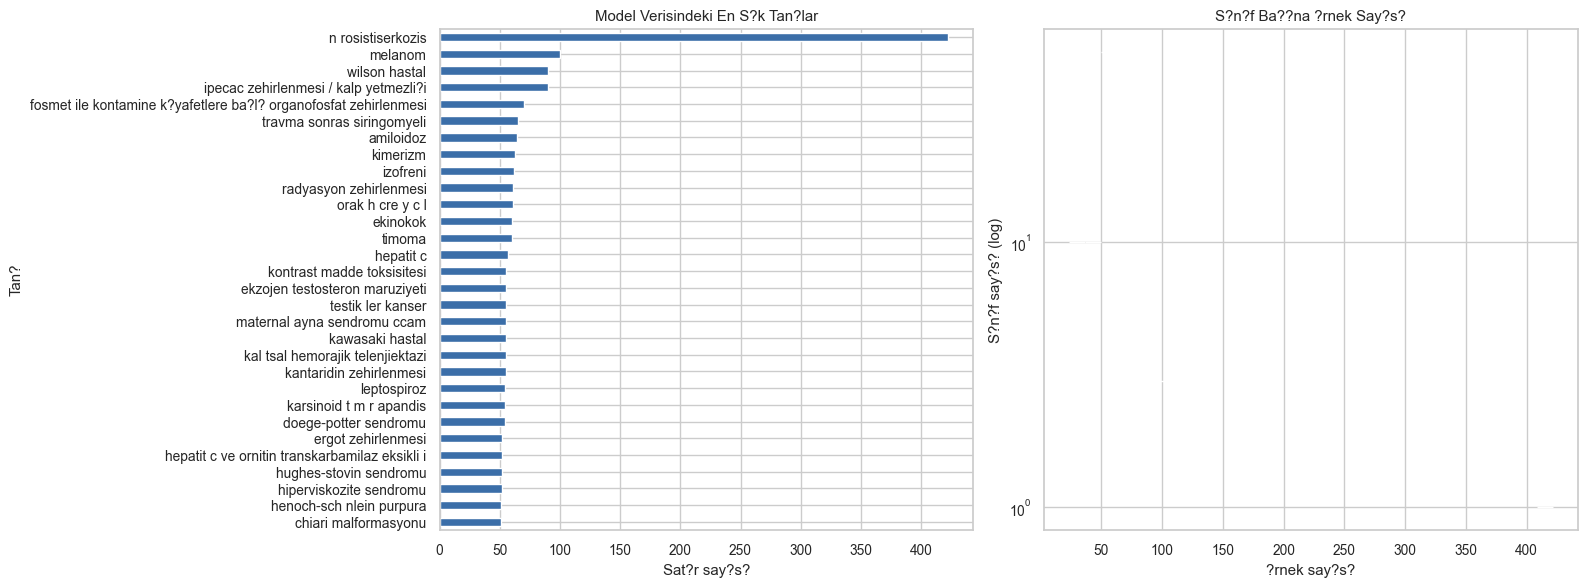

In [7]:
class_summary = df_model["target"].value_counts().rename_axis("target").reset_index(name="count")
imbalance_ratio = class_summary["count"].max() / class_summary["count"].min()

display(class_summary.head(35))
print("Class min/max:", int(class_summary["count"].min()), int(class_summary["count"].max()))
print("Imbalance ratio before train balancing:", round(imbalance_ratio, 4))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
class_summary.head(30).sort_values("count").plot(
    kind="barh", x="target", y="count", legend=False, ax=axes[0], color="#3b6ea8"
)
axes[0].set_title("Model Verisindeki En S?k Tan?lar")
axes[0].set_xlabel("Sat?r say?s?")
axes[0].set_ylabel("Tan?")

sns.histplot(class_summary["count"], bins=30, ax=axes[1], color="#d88732", log_scale=(False, True))
axes[1].set_title("S?n?f Ba??na ?rnek Say?s?")
axes[1].set_xlabel("?rnek say?s?")
axes[1].set_ylabel("S?n?f say?s? (log)")
plt.tight_layout()
plt.show()

## 3. Modelleme

?? model de ayn? `model_text` alan? ?zerinde e?itilir. Train/test ayr?m? ?nce yap?l?r; s?n?f dengeleme yaln?zca train taraf?nda uygulan?r. B?ylece test seti ger?ek da??l?m? korur.

In [8]:
X = df_model["model_text"]
y = df_model["target"]
indices = df_model.index

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X,
    y,
    indices,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train rows:", len(X_train))
print("Test rows:", len(X_test))
print("Train classes:", y_train.nunique())
print("Test classes:", y_test.nunique())
print("Train class min/max before balancing:", int(y_train.value_counts().min()), int(y_train.value_counts().max()))

Train rows: 3529
Test rows: 883
Train classes: 80
Test classes: 80
Train class min/max before balancing: 18 337


In [9]:
def balance_training_data(X_values, y_values, random_state=RANDOM_STATE):
    data = pd.DataFrame({"text": list(X_values), "target": list(y_values)})
    counts = data["target"].value_counts()
    target_size = int(counts.max())
    rng = np.random.default_rng(random_state)

    pieces = []
    for _, group in data.groupby("target", sort=False):
        sampled_indices = rng.choice(group.index.to_numpy(), size=target_size, replace=len(group) < target_size)
        pieces.append(data.loc[sampled_indices].copy())

    balanced = pd.concat(pieces).sample(frac=1, random_state=random_state).reset_index(drop=True)
    return balanced["text"], balanced["target"]


def make_word_tfidf(max_features=90_000):
    return TfidfVectorizer(
        lowercase=False,
        sublinear_tf=True,
        stop_words=list(TR_STOPWORDS),
        ngram_range=(1, 3),
        min_df=1,
        max_df=0.92,
        max_features=max_features,
    )


def make_pipeline(clf):
    return Pipeline([
        ("features", make_word_tfidf()),
        ("clf", clf),
    ])

model_specs = [
    {
        "name": "ComplementNB word_tfidf balanced_train_max",
        "family": "Complement Naive Bayes",
        "clf": ComplementNB(alpha=0.08),
    },
    {
        "name": "PassiveAggressive word_tfidf balanced_train_max",
        "family": "Passive-Aggressive Linear Classifier",
        "clf": PassiveAggressiveClassifier(C=0.5, random_state=RANDOM_STATE, max_iter=2_000, tol=1e-4),
    },
    {
        "name": "SGD modified_huber word_tfidf balanced_train_max",
        "family": "SGD Modified Huber Linear Classifier",
        "clf": SGDClassifier(
            loss="modified_huber",
            alpha=1e-5,
            penalty="l2",
            max_iter=2_000,
            tol=1e-4,
            random_state=RANDOM_STATE,
        ),
    },
]

X_train_balanced, y_train_balanced = balance_training_data(X_train, y_train)
balanced_counts = y_train_balanced.value_counts()

balance_check = pd.DataFrame([{
    "rows_before": len(X_train),
    "rows_after": len(X_train_balanced),
    "class_count": int(balanced_counts.size),
    "min_class_after": int(balanced_counts.min()),
    "max_class_after": int(balanced_counts.max()),
    "max_min_ratio_after": round(float(balanced_counts.max() / balanced_counts.min()), 4),
}])

display(balance_check)
display(pd.DataFrame([{ "model": spec["name"], "family": spec["family"] } for spec in model_specs]))

,rows_before,rows_after,class_count,min_class_after,max_class_after,max_min_ratio_after
0,3529,26960,80,337,337,1.0


,model,family
0,ComplementNB word_tfidf balanced_train_max,Complement Naive Bayes
1,PassiveAggressive word_tfidf balanced_train_max,Passive-Aggressive Linear Classifier
2,SGD modified_huber word_tfidf balanced_train_max,SGD Modified Huber Linear Classifier


In [10]:
test_rows = []
fitted_models = {}
predictions = {}

for spec in model_specs:
    print("Training:", spec["name"])
    model = make_pipeline(spec["clf"])
    model.fit(X_train_balanced, y_train_balanced)
    y_pred = model.predict(X_test)

    fitted_models[spec["name"]] = model
    predictions[spec["name"]] = y_pred

    precision, recall, weighted_f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="weighted", zero_division=0
    )

    test_rows.append({
        "model": spec["name"],
        "family": spec["family"],
        "train_rows_after_balancing": len(X_train_balanced),
        "fit_min_class": int(balanced_counts.min()),
        "fit_max_class": int(balanced_counts.max()),
        "fit_max_min_ratio": round(float(balanced_counts.max() / balanced_counts.min()), 4),
        "test_accuracy": accuracy_score(y_test, y_pred),
        "test_balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "test_macro_f1": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "test_weighted_f1": weighted_f1,
        "test_weighted_precision": precision,
        "test_weighted_recall": recall,
    })

test_results = pd.DataFrame(test_rows).sort_values(
    ["test_macro_f1", "test_balanced_accuracy", "test_weighted_f1"],
    ascending=False,
).reset_index(drop=True)

best_model_name = test_results.iloc[0]["model"]
best_model = fitted_models[best_model_name]
y_pred_best = predictions[best_model_name]

print("Final selected model:", best_model_name)
display(test_results)

Training: ComplementNB word_tfidf balanced_train_max
Training: PassiveAggressive word_tfidf balanced_train_max
Training: SGD modified_huber word_tfidf balanced_train_max
Final selected model: SGD modified_huber word_tfidf balanced_train_max


,model,family,train_rows_after_balancing,fit_min_class,fit_max_class,fit_max_min_ratio,test_accuracy,test_balanced_accuracy,test_macro_f1,test_weighted_f1,test_weighted_precision,test_weighted_recall
0,SGD modified_huber word_tfidf balanced_train_max,SGD Modified Huber Linear Classifier,26960,337,337,1.0,0.992072,0.989706,0.989699,0.991695,0.993298,0.992072
1,PassiveAggressive word_tfidf balanced_train_max,Passive-Aggressive Linear Classifier,26960,337,337,1.0,0.980747,0.975000,0.979685,0.978159,0.984009,0.980747
2,ComplementNB word_tfidf balanced_train_max,Complement Naive Bayes,26960,337,337,1.0,0.951302,0.985483,0.969551,0.951737,0.975696,0.951302


                                                                  precision    recall  f1-score   support

                                                  addison hastal       0.70      1.00      0.82         7
                                              afrika uyku hastal       1.00      1.00      1.00         8
                                                       amiloidoz       1.00      1.00      1.00        13
                                                      anafilaksi       1.00      1.00      1.00         5
                                  araknoid kist / crush sendromu       1.00      1.00      1.00        10
                               arapnel kaynakl stafilokokal apse       1.00      1.00      1.00         7
                                                  bak r alerjisi       1.00      1.00      1.00         9
                          bal k tenyas enfeksiyonu b12 eksikli i       1.00      1.00      1.00         7
                                             

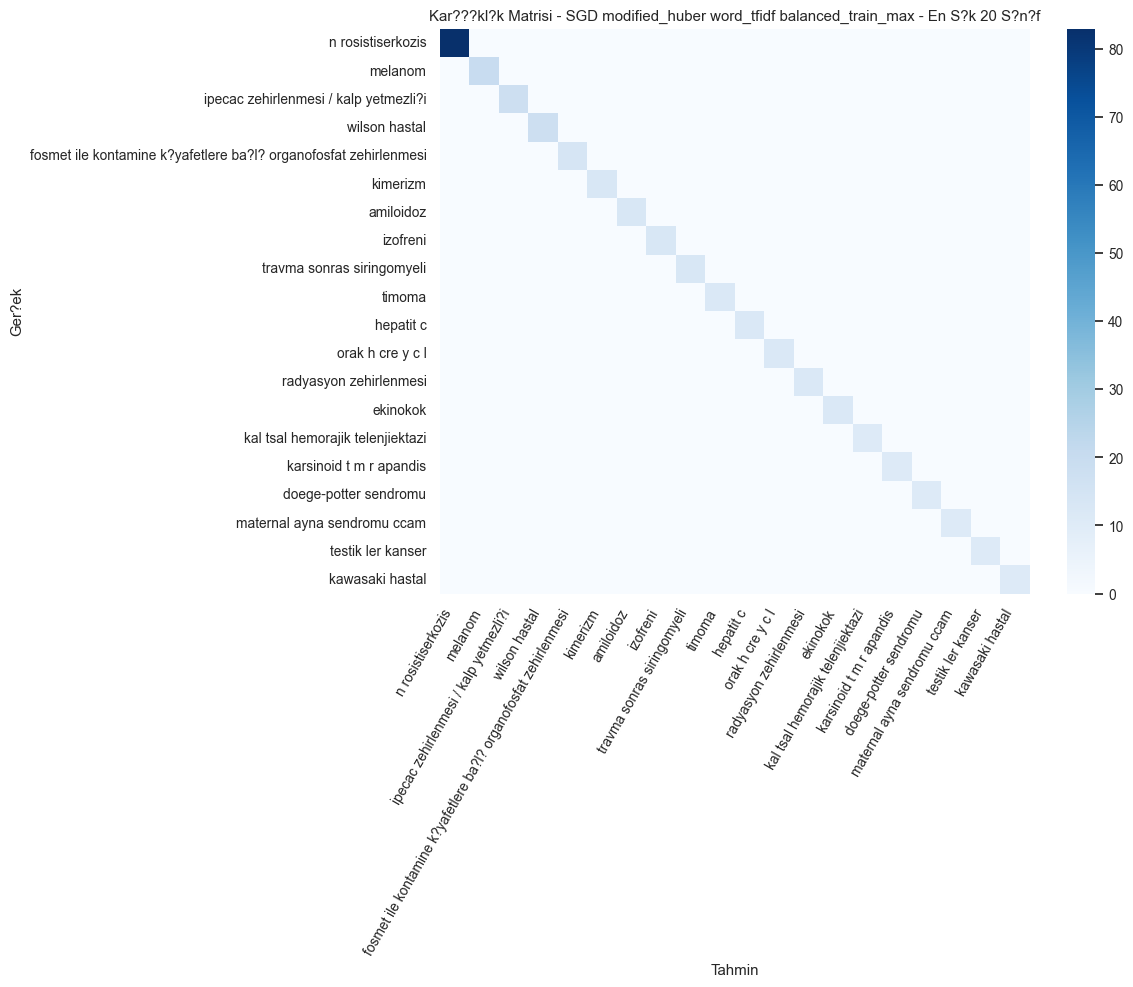

In [11]:
report_text = classification_report(y_test, y_pred_best, zero_division=0)
print(report_text)

top_labels = y_test.value_counts().head(20).index.tolist()
cm = confusion_matrix(y_test, y_pred_best, labels=top_labels)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, cmap="Blues", xticklabels=top_labels, yticklabels=top_labels)
plt.title(f"Kar???kl?k Matrisi - {best_model_name} - En S?k 20 S?n?f")
plt.xlabel("Tahmin")
plt.ylabel("Ger?ek")
plt.xticks(rotation=60, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [12]:
error_df = df_model.loc[idx_test, [
    "season", "episode", "speaker", "text", "Symptom", "Test", "Drug", "Procedure", "Organ", "target",
]].copy()
error_df["prediction"] = y_pred_best
error_df["is_correct"] = error_df["target"].values == error_df["prediction"].values

print("Correct prediction ratio:", round(error_df["is_correct"].mean(), 4))
print("Wrong prediction count:", int((~error_df["is_correct"]).sum()))
display(error_df[~error_df["is_correct"]].head(25))

Correct prediction ratio: 0.9921
Wrong prediction count: 7


,season,episode,speaker,text,Symptom,Test,Drug,Procedure,Organ,target,prediction,is_correct
2728,4,7,Cole,Hasta suya girer girmez bilincini kaybetti.,bilinç kaybı,,,,,n rosistiserkozis,lyme hastal,False
1441,3,1,House,Sigara içmesi durumu açıklamaz; akciğerler yerine başka bir şeye bakmalıyız.,,,,,akciğer,iskorb t,addison hastal,False
2191,4,6,Terzi,Plazmaferez ve kemoterapi ayarlayacağım.,,,,"kemoterapi, plazmaferez",kan,talyum zehirlenmesi,n rosistiserkozis,False
1444,3,1,House,Juguler ven belirgin; sorun akciğerde değil kalpte olabilir.,"juguler ven dolgunluğu, nefes darlığı",,,iğne dekompresyonu,kalp,iskorb t,addison hastal,False
2717,4,7,House,"Hasta JRA olabilir, steroid başlanmalı.",JRA,,steroid,,,n rosistiserkozis,lyme hastal,False
1449,3,1,House,"Felç taklit değilse, görünen paralizi gerçek bir nörolojik belirti olabilir.",felç,,,,sinir sistemi,iskorb t,addison hastal,False
2207,4,7,Kutner,Çocuğun baş ağrısı var. Fıstık gibi asetaminofen yutuyor...,baş ağrısı,,asetaminofen,,baş,lyme hastal,n rosistiserkozis,False


## 4. Canl?ya Alma ve Etik

Model paketi tek dosya olarak kaydedilir. Paket i?inde en iyi model, ?? aday model, metrikler, s?n?f listesi, temizleme ?zeti ve etik not bulunur.

In [13]:
data_summary = {
    "raw_rows": int(raw_row_count),
    "blank_rows_removed": int(blank_row_count),
    "valid_rows_after_label_text_cleaning": int(len(df_clean)),
    "raw_valid_class_count": int(raw_valid_class_count),
    "canonical_class_count_before_rare_filter": int(canonical_class_count),
    "rare_class_count_removed": int(rare_class_count),
    "rare_rows_removed": int(rare_row_count),
    "duplicate_rows_removed": int(duplicate_rows_removed),
    "model_rows": int(len(df_model)),
    "class_count": int(df_model["target"].nunique()),
    "min_class_count_used": int(MIN_CLASS_COUNT),
    "case_context_token_limit": int(CASE_CONTEXT_TOKEN_LIMIT),
    "class_imbalance_ratio_before_train_balancing": float(round(imbalance_ratio, 4)),
    "train_rows_before_balancing": int(len(X_train)),
    "train_rows_after_balancing": int(len(X_train_balanced)),
    "test_rows": int(len(X_test)),
    "final_fit_min_class": int(balanced_counts.min()),
    "final_fit_max_class": int(balanced_counts.max()),
    "final_fit_balance_ratio": float(round(balanced_counts.max() / balanced_counts.min(), 4)),
    "target_column": TARGET_COLUMN,
    "selection_metric": SELECTION_METRIC,
    "text_feature_columns": TEXT_FEATURE_COLUMNS,
    "meta_feature_columns": META_FEATURE_COLUMNS,
    "case_context_columns": CASE_CONTEXT_COLUMNS,
    "excluded_leakage_columns": EXCLUDED_LEAKAGE_COLUMNS,
    "ethics_note": "Educational House M.D. NLP model; not a clinical diagnostic or treatment tool.",
}

model_package = {
    "pipeline": best_model,
    "candidate_models": fitted_models,
    "best_model_name": best_model_name,
    "target_column": TARGET_COLUMN,
    "classes": sorted(df_model["target"].unique().tolist()),
    "label_synonym_map": LABEL_SYNONYM_MAP,
    "data_summary": data_summary,
    "class_summary": class_summary.to_dict(orient="records"),
    "test_results": test_results.to_dict(orient="records"),
    "classification_report": report_text,
    "saved_at": datetime.now().isoformat(timespec="seconds"),
}

MODEL_PATH.parent.mkdir(exist_ok=True)
joblib.dump(model_package, MODEL_PATH)

print("Model package saved:", MODEL_PATH.resolve())
display(pd.DataFrame([data_summary]))

Model package saved: C:\Users\moham\Desktop\NLP_Project\models\best_housemd_diagnosis_model.joblib


,raw_rows,blank_rows_removed,valid_rows_after_label_text_cleaning,raw_valid_class_count,canonical_class_count_before_rare_filter,rare_class_count_removed,rare_rows_removed,duplicate_rows_removed,model_rows,class_count,...,final_fit_min_class,final_fit_max_class,final_fit_balance_ratio,target_column,selection_metric,text_feature_columns,meta_feature_columns,case_context_columns,excluded_leakage_columns,ethics_note
0,7282,0,5415,633,629,549,1003,0,4412,80,...,337,337,1.0,correct_prediction,test_macro_f1,"[text, Symptom, Test, Drug, Procedure, Organ]","[speaker, Intent, diagnosis_stage, Emotion, Sarcasm]","[Symptom, Test, Drug, Procedure, Organ, medical_entities]","[correct_prediction, model_prediction]",Educational House M.D. NLP model; not a clinical diagnostic or treatment tool.


In [14]:
def scores_to_topk(model, model_text, top_k=5):
    classes = np.array(model.classes_)
    if hasattr(model, "predict_proba"):
        scores = model.predict_proba([model_text])[0]
    elif hasattr(model, "decision_function"):
        scores = np.asarray(model.decision_function([model_text]))
        if scores.ndim == 2:
            scores = scores[0]
    else:
        prediction = model.predict([model_text])[0]
        return pd.DataFrame([{"rank": 1, "prediction": prediction, "score": np.nan}])

    order = np.argsort(scores)[::-1][:top_k]
    return pd.DataFrame({
        "rank": np.arange(1, len(order) + 1),
        "prediction": classes[order],
        "score": scores[order],
    })


def build_case_context_from_fields(**fields):
    fact_values = [fields.get(col, "") for col in ["Symptom", "Test", "Drug", "Procedure", "Organ"]]
    entity_values = [fields.get("medical_entities", "")]
    fact_text = unique_token_join([normalize_text(value) for value in fact_values])
    entity_text = unique_token_join([extract_medical_entities(value) for value in entity_values])
    return (fact_text + " " + entity_text).strip()


def predict_diagnosis_from_fields(model_package=model_package, top_k=5, **fields):
    row = pd.Series(fields)
    row_text = build_row_text(row)
    case_context = fields.get("case_context") or build_case_context_from_fields(**fields)
    model_text = (row_text + " vaka_baglam " + case_context).strip()
    return scores_to_topk(model_package["pipeline"], model_text, top_k=top_k)


def bot_answer(model_package=model_package, top_k=3, **fields):
    predictions = predict_diagnosis_from_fields(model_package=model_package, top_k=top_k, **fields)
    first = predictions.iloc[0]
    alternatives = ", ".join(predictions["prediction"].astype(str).tolist()[1:])
    return {
        "answer": (
            f"Bu House M.D. veri seti modeline g?re en olas? etiket: {first['prediction']}. "
            f"Alternatifler: {alternatives}. Bu ??kt? e?itim ama?l?d?r; klinik tan? yerine ge?mez."
        ),
        "top_predictions": predictions,
    }

example_case = {
    "text": "Hasta n?bet ge?irdi, MR g?r?nt?s?nde beyinde lezyon var.",
    "Symptom": "n?bet",
    "Test": "MR",
    "Organ": "beyin",
    "Intent": "a??klama",
    "diagnosis_stage": "hipotez",
    "Emotion": "n?tr",
    "Sarcasm": "0",
}

demo = bot_answer(**example_case)
print(demo["answer"])
display(demo["top_predictions"])

Bu House M.D. veri seti modeline g?re en olas? etiket: hepatit c. Alternatifler: s ngersi ensefalit, fosmet ile kontamine k?yafetlere ba?l? organofosfat zehirlenmesi. Bu ??kt? e?itim ama?l?d?r; klinik tan? yerine ge?mez.


,rank,prediction,score
0,1,hepatit c,0.191955
1,2,s ngersi ensefalit,0.164355
2,3,fosmet ile kontamine k?yafetlere ba?l? organofosfat zehirlenmesi,0.147034


## 5. Yaz?l? Rapor ve S?zl? Sunum ?zeti

**Problem tan?m?:** House M.D. veri setindeki replik/vaka bilgilerini kullanarak tan? etiketi tahmini yapan ?ok s?n?fl? NLP modeli geli?tirildi.

**Veri haz?rlama:** Bo?/ge?ersiz hedefler (`""`, `none`, `1`, `0`) temizlendi. Yaz?m fark? olan baz? tan?lar canonical etikete birle?tirildi. ?ok seyrek s?n?flar g?venilir train/test ayr?m? i?in d??ar?da b?rak?ld?.

**?n i?leme ve ?zellik se?imi:** T?rk?e karakterler korunarak normalizasyon yap?ld?. Replik metni, semptom, test, ila?, prosed?r, organ, konu?mac? ve tan? a?amas? alanlar? birle?tirildi. Final modelde hedef etiketi kullanmadan ayn? vaka i?indeki klinik alanlardan case-aware ba?lam ?retildi. ?zellik ??kar?m? i?in TF-IDF word n-gram `(1, 3)` kullan?ld?.

**Modelleme:** ?? model ayn? dosya ve ayn? veri haz?rlama hatt? ?zerinde kar??la?t?r?ld?: ComplementNB, PassiveAggressiveClassifier ve SGDClassifier (`modified_huber`). E?itim setinde s?n?flar en b?y?k train s?n?f? kadar ?rneklenerek e?itlendi; test seti ger?ek da??l?mda b?rak?ld?.

**Canl?ya alma:** En iyi model ve aday modeller `models/best_housemd_diagnosis_model.joblib` i?inde paketlendi. Bot fonksiyonu ilk tahmini ve alternatif tan?lar? d?nd?r?r.

**Etik not:** Bu ?al??ma e?itim ama?l?d?r. House M.D. kurgusal/veri seti ba?lam?nda tahmin ?retir; ger?ek klinik tan?, tedavi veya triyaj arac? olarak kullan?lmamal?d?r. Ger?ek hasta verisiyle kullan?m i?in anonimle?tirme, a??k r?za, uzman denetimi ve veri g?venli?i gerekir.

**Sunum ak??? ?nerisi:**

1. Proje amac? ve veri seti.
2. Veri kalitesi sorunlar? ve temizleme kararlar?.
3. Case-aware ?zellik m?hendisli?i.
4. ?? modelin kar??la?t?rmal? sonu?lar?.
5. En iyi model, hata analizi ve demo bot cevab?.
6. Canl?ya alma paketi ve etik s?n?rlar.